In [1]:
pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

df = pd.DataFrame({
    "sessions": np.random.randint(1, 50, n),
    "time_spent": np.random.randint(5, 300, n),  # minutes
    "test_score": np.random.randint(30, 100, n),
    "questions_attempted": np.random.randint(10, 200, n),
    "last_active_days": np.random.randint(0, 30, n),
})

# Target variable (conversion)
df["converted"] = (
    (df["sessions"] > 20) &
    (df["test_score"] > 60) &
    (df["last_active_days"] < 10)
).astype(int)

df.head()

,sessions,time_spent,test_score,questions_attempted,last_active_days,converted
0,39,27,34,184,0,0
1,29,254,67,93,11,0
2,15,14,42,31,23,0
3,43,250,60,36,12,0
4,8,104,76,90,9,0


In [5]:
df.describe()
df["converted"].value_counts()

converted
0    438
1     62
Name: count, dtype: int64

In [9]:
# Create new features
df["engagement_score"] = df["sessions"] * df["time_spent"]
df["performance_ratio"] = df["test_score"] / df["questions_attempted"]

# Handle potential division issues
df["performance_ratio"] = df["performance_ratio"].fillna(0)

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("converted", axis=1)
y = df["converted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [17]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.97
ROC-AUC: 0.9470108695652174
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        92
           1       0.86      0.75      0.80         8

    accuracy                           0.97       100
   macro avg       0.92      0.87      0.89       100
weighted avg       0.97      0.97      0.97       100



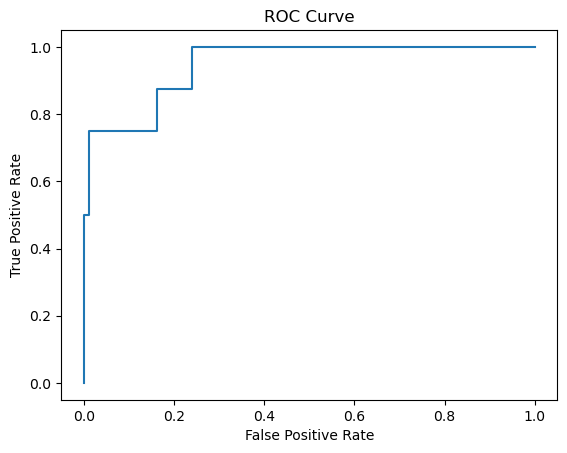

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [21]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

feature_importance

,feature,coefficient
2,test_score,0.113519
0,sessions,0.110573
5,engagement_score,0.000248
1,time_spent,-0.004727
3,questions_attempted,-0.014744
6,performance_ratio,-0.290632
4,last_active_days,-0.441495


In [23]:
df_test = X_test.copy()
df_test["conversion_probability"] = y_prob

df_test.head()

,sessions,time_spent,test_score,questions_attempted,last_active_days,engagement_score,performance_ratio,conversion_probability
361,37,17,92,81,28,629,1.135802,0.000494
73,36,104,46,91,1,3744,0.505495,0.348249
374,18,268,90,199,22,4824,0.452261,0.000126
155,37,256,65,21,15,9472,3.095238,0.027679
104,11,13,74,167,8,143,0.443114,0.007629
